We import all the libraries we’ll need

In [ ]:
# === Cell 1: Imports ===
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

from pathlib import Path
import os

# Hugging Face
from transformers import BlipProcessor, BlipForConditionalGeneration


Set up paths, constants, and hyperparameters

In [ ]:
# === Cell 2: Configs ===
REPO = Path.cwd().parent   # repo root (adjust if needed)

DATA_DIR = REPO / "data" / "synthetic"
CAPTIONS_CSV = DATA_DIR / "captions.csv"
OUTPUTS_DIR = REPO / "outputs"
MODELS_DIR = OUTPUTS_DIR / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

# Hyperparameters
BATCH_SIZE = 4
LR = 5e-5
EPOCHS = 3
SEED = 1337

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Load `captions.csv` to Print sample rows, check if all filenames actually exist on disk, warn if any missing files are found.

In [ ]:
# === Cell 3: Validate dataset ===
df = pd.read_csv(CAPTIONS_CSV)
print("Samples:", len(df))
print(df.head())

missing = []
for i, row in df.iterrows():
    fp = REPO / row["filename"]
    if not fp.exists():
        missing.append(row["filename"])

print("Missing files:", len(missing))
if missing:
    print("First few missing:", missing[:5])


Dataset Class (image → caption pairs)

In [ ]:
# === Cell 4: Dataset Class (image -> caption pairs) ===
class MediaCaptionDataset(Dataset):
    def __init__(self, df, processor, transform=None):
        self.df = df.reset_index(drop=True)
        self.processor = processor
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = REPO / row["filename"]
        image = Image.open(img_path).convert("RGB")
        inputs = self.processor(images=image, text=row["caption"], return_tensors="pt", padding="max_length", truncation=True, max_length=32)
        # squeeze batch dim
        inputs = {k: v.squeeze(0) for k,v in inputs.items()}
        return inputs


Processor & Splits
Initialize Hugging Face BLIP processor (handles text+images)
Split the dataset

In [ ]:
# === Cell 5: Processor & Splits ===
from sklearn.model_selection import train_test_split

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")

# Split dataset (70/15/15)
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["class"], random_state=SEED)
val_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["class"], random_state=SEED)

train_ds = MediaCaptionDataset(train_df, processor)
val_ds   = MediaCaptionDataset(val_df, processor)
test_ds  = MediaCaptionDataset(test_df, processor)

def collate_fn(batch):
    return {k: torch.stack([d[k] for d in batch]) for k in batch[0]}

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print("Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))


Load BLIP

In [ ]:
# === Cell 6: Load BLIP ===
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model = model.to(device)

optimizer = optim.AdamW(model.parameters(), lr=LR)


Training Loop

In [ ]:
# === Cell 7: Training Loop ===
def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0
    for batch in loader:
        batch = {k: v.to(device) for k,v in batch.items()}
        outputs = model(**batch, labels=batch["input_ids"])
        loss = outputs.loss
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(loader)

def eval_model(model, loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for batch in loader:
            batch = {k: v.to(device) for k,v in batch.items()}
            outputs = model(**batch, labels=batch["input_ids"])
            total_loss += outputs.loss.item()
    return total_loss / len(loader)

best_val = float("inf")
for epoch in range(EPOCHS):
    tr_loss = train_one_epoch(model, train_loader, optimizer)
    val_loss = eval_model(model, val_loader)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train loss {tr_loss:.3f} | Val loss {val_loss:.3f}")
    if val_loss < best_val:
        best_val = val_loss
        model.save_pretrained(MODELS_DIR/"blip_finetuned")
        processor.save_pretrained(MODELS_DIR/"blip_finetuned")


Caption Generation Demo

In [ ]:
# === Cell 8: Caption generation demo ===
model.eval()

for i in range(3):
    row = test_df.sample(1).iloc[0]
    img_path = REPO / row["filename"]
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=20)
    pred_caption = processor.decode(out[0], skip_special_tokens=True)
    print(f"GT: {row['caption']}")
    print(f"Pred: {pred_caption}")
    display(image)


Membership Inference Attack (Loss Collection)

In [ ]:
# === Cell 9: Membership Inference Attack ===
def get_perplexity(model, processor, df_subset):
    losses = []
    model.eval()
    with torch.no_grad():
        for _, row in df_subset.iterrows():
            img_path = REPO / row["filename"]
            image = Image.open(img_path).convert("RGB")
            inputs = processor(images=image, text=row["caption"], return_tensors="pt", truncation=True, padding=True).to(device)
            outputs = model(**inputs, labels=inputs["input_ids"])
            losses.append(outputs.loss.item())
    return np.array(losses)

train_losses = get_perplexity(model, processor, train_df)
test_losses  = get_perplexity(model, processor, test_df)

labels = np.array([1]*len(train_losses) + [0]*len(test_losses))  # 1=member, 0=nonmember
scores = -np.concatenate([train_losses, test_losses])  # higher score = more likely member

auc = roc_auc_score(labels, scores)
print("MIA ROC AUC:", auc)

fpr, tpr, _ = roc_curve(labels, scores)
plt.plot(fpr, tpr, label=f"AUC={auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Membership Inference Attack (BLIP)")
plt.legend()
plt.show()


MIA ROC Curve + Accuracy

In [ ]:
# === Cell 10: Extraction Attack Demo ===
memorized = []
for _, row in train_df.sample(5, random_state=SEED).iterrows():
    img_path = REPO / row["filename"]
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=20)
    pred = processor.decode(out[0], skip_special_tokens=True)
    if pred.strip().lower() == row["caption"].strip().lower():
        memorized.append((row["caption"], pred))
    print(f"GT: {row['caption']} | Pred: {pred}")

print("Exact memorized cases:", len(memorized))


In [ ]:
# === Cell 10: MIA ROC Curve + Accuracy ===
labels = np.array([1]*len(train_losses) + [0]*len(test_losses))  # 1 = member, 0 = nonmember
scores = -np.concatenate([train_losses, test_losses])  # lower loss = more likely member

auc = roc_auc_score(labels, scores)
print("MIA ROC AUC:", auc)

# Simple threshold attack at 0.5 quantile
threshold = np.median(scores)
preds = (scores >= threshold).astype(int)
acc = (preds == labels).mean()
print("MIA attack accuracy:", acc)

# ROC curve plot
fpr, tpr, _ = roc_curve(labels, scores)
plt.plot(fpr, tpr, label=f"AUC={auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Membership Inference Attack (BLIP)")
plt.legend()
plt.show()


Extraction Attack Demo (with Canaries)

In [ ]:
# === Cell 11: Extraction Attack Demo (with Canaries) ===
model.eval()
memorized = []
canary_hits = []

def generate_caption(image_path):
    image = Image.open(image_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=20)
    return processor.decode(out[0], skip_special_tokens=True)

# Check 5 random training samples
print("🔎 Checking random training samples...\n")
for _, row in train_df.sample(5, random_state=SEED).iterrows():
    img_path = REPO / row["filename"]
    pred = generate_caption(img_path)
    gt = row["caption"].strip().lower()
    pred_norm = pred.strip().lower()

    print(f"GT: {row['caption']}")
    print(f"Pred: {pred}\n")

    if gt == pred_norm:
        memorized.append((gt, pred))

# Explicitly check canaries
print("\n🔎 Checking canary samples...\n")
for _, row in train_df.iterrows():
    if "canary" in row["caption"].lower():
        img_path = REPO / row["filename"]
        pred = generate_caption(img_path)
        gt = row["caption"]
        print(f"Canary GT: {gt}")
        print(f"Predicted: {pred}\n")
        if pred.strip().lower() == gt.strip().lower():
            canary_hits.append((gt, pred))

print("=== Summary ===")
print("Exact random memorized captions:", len(memorized))
print("Exact canary leaks:", len(canary_hits))


Test Set Qualitative Examples

In [ ]:
# === Cell 12: Test Set Qualitative Examples ===
for _, row in test_df.sample(3, random_state=SEED).iterrows():
    img_path = REPO / row["filename"]
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=20)
    pred_caption = processor.decode(out[0], skip_special_tokens=True)

    print(f"GT (test caption): {row['caption']}")
    print(f"Pred: {pred_caption}")
    display(image)


 Save Attack Results

In [ ]:
# === Cell 13 (Updated): Save Attack Results with Figures ===
import json

RESULTS_DIR = OUTPUTS_DIR / "results"
FIGURES_DIR = OUTPUTS_DIR / "figures"   # <-- add this line
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

results = {
    "mia": {
        "roc_auc": float(auc),
        "attack_accuracy": float(acc),
        "avg_train_loss": float(train_losses.mean()),
        "avg_test_loss": float(test_losses.mean()),
        "threshold_used": float(threshold),
        "figures": {
            "roc_curve": str(FIGURES_DIR / "mia_roc_curve.png"),
            "loss_histogram": str(FIGURES_DIR / "loss_histogram.png")
        }
    },
    "extraction": {
        "exact_memorized_count": len(memorized),
        "exact_canary_leaks": len(canary_hits),
        "total_train_samples": len(train_df),
        "examples_file": str(RESULTS_DIR / "canary_examples.json"),
        "figures": {
            "caption_comparison": str(FIGURES_DIR / "caption_comparison.png"),
            "distorted_attack": str(FIGURES_DIR / "distorted_attack.png")
        }
    }
}

out_path = RESULTS_DIR / "attack_report.json"
with open(out_path, "w") as f:
    json.dump(results, f, indent=2)

print("✅ Saved attack results with figure paths to:", out_path)
print(json.dumps(results, indent=2))


In [ ]:
# === Cell 14: Save ROC Curve ===
FIGURES_DIR = OUTPUTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC={auc:.2f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Membership Inference Attack (BLIP)")
plt.legend()
roc_path = FIGURES_DIR / "mia_roc_curve.png"
plt.savefig(roc_path)
print("✅ Saved ROC curve to:", roc_path)


In [ ]:
# === Cell 15: Train vs Test Loss Histogram ===
plt.figure()
plt.hist(train_losses, bins=15, alpha=0.7, label="Train (members)")
plt.hist(test_losses, bins=15, alpha=0.7, label="Test (non-members)")
plt.xlabel("Loss")
plt.ylabel("Frequency")
plt.title("Train vs Test Loss Distribution")
plt.legend()
hist_path = FIGURES_DIR / "loss_histogram.png"
plt.savefig(hist_path)
print("✅ Saved loss histogram to:", hist_path)


In [ ]:
# === Cell 16: Save Canary Leak Evidence ===
canary_examples = []
for gt, pred in canary_hits:
    canary_examples.append({"ground_truth": gt, "predicted": pred})

canary_path = RESULTS_DIR / "canary_examples.json"
with open(canary_path, "w") as f:
    json.dump(canary_examples, f, indent=2)

print("✅ Saved canary examples to:", canary_path)


In [ ]:
# === Cell 17: Caption Comparison Grid (Test Samples) ===
rows = test_df.sample(6, random_state=SEED).iterrows()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, (_, row) in zip(axes.flatten(), rows):
    img_path = REPO / row["filename"]
    image = Image.open(img_path).convert("RGB")
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=20)
    pred = processor.decode(out[0], skip_special_tokens=True)

    ax.imshow(image)
    ax.axis("off")
    ax.set_title(f"GT: {row['caption']}\nPred: {pred}", fontsize=9)

grid_path = FIGURES_DIR / "caption_comparison.png"
plt.tight_layout()
plt.savefig(grid_path)
print("✅ Saved caption comparison grid to:", grid_path)


In [ ]:
# === Cell 18: Distorted Image Attack Demo ===
from torchvision import transforms as T

distort = T.Compose([
    T.Resize((224,224)),
    T.RandomPosterize(bits=2),
    T.RandomSolarize(threshold=128),
    T.RandomRotation(degrees=45)
])

row = test_df.sample(1, random_state=SEED).iloc[0]
img_path = REPO / row["filename"]
image = Image.open(img_path).convert("RGB")
distorted = distort(image)

inputs = processor(images=distorted, return_tensors="pt").to(device)
out = model.generate(**inputs, max_new_tokens=20)
pred = processor.decode(out[0], skip_special_tokens=True)

plt.figure()
plt.subplot(1,2,1); plt.imshow(image); plt.axis("off"); plt.title("Original")
plt.subplot(1,2,2); plt.imshow(distorted); plt.axis("off"); plt.title("Distorted")
plt.suptitle(f"Predicted Caption: {pred}")
distort_path = FIGURES_DIR / "distorted_attack.png"
plt.savefig(distort_path)
print("✅ Saved distorted attack demo to:", distort_path)


✅ Saved external non-member demo to: c:\Users\Rishav\Documents\GitHub\CS690FStartup\outputs\figures\external_nonmember.png


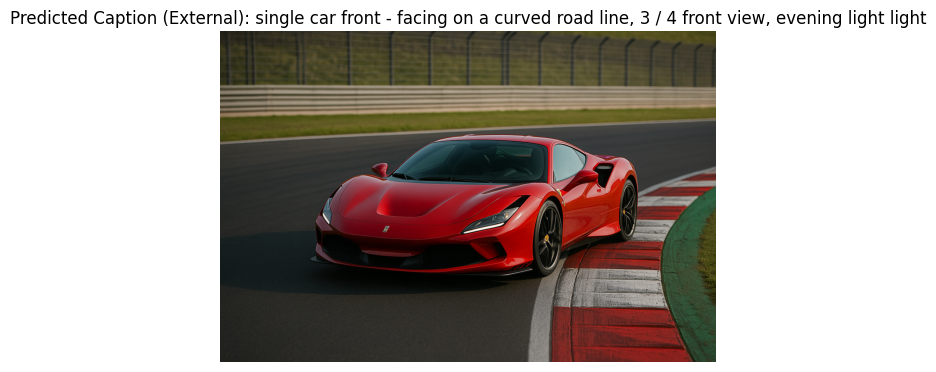

In [22]:
# === Cell 19: External Non-Member Image Demo ===
# Path to an external test image (not in captions.csv)
external_img_path = REPO / "data" / "external" / "car_external.jpg"

# Make sure the folder exists and image is placed there manually
if not external_img_path.exists():
    print(f"⚠️ External image not found: {external_img_path}")
else:
    image = Image.open(external_img_path).convert("RGB")

    # Run BLIP captioning
    inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=20)
    pred = processor.decode(out[0], skip_special_tokens=True)

    # Show the image + caption
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Predicted Caption (External): {pred}")
    ext_path = FIGURES_DIR / "external_nonmember.png"
    plt.savefig(ext_path)
    print("✅ Saved external non-member demo to:", ext_path)


🔎 External Non-Member Results
Predicted Caption: single car front - facing on a curved road line, 3 / 4 front view, evening light light
External Loss: 8.5702
Avg Train Loss: 0.7677
Avg Test Loss: 2.5704
✅ Saved external non-member demo to: c:\Users\Rishav\Documents\GitHub\CS690FStartup\outputs\figures\external_nonmember.png


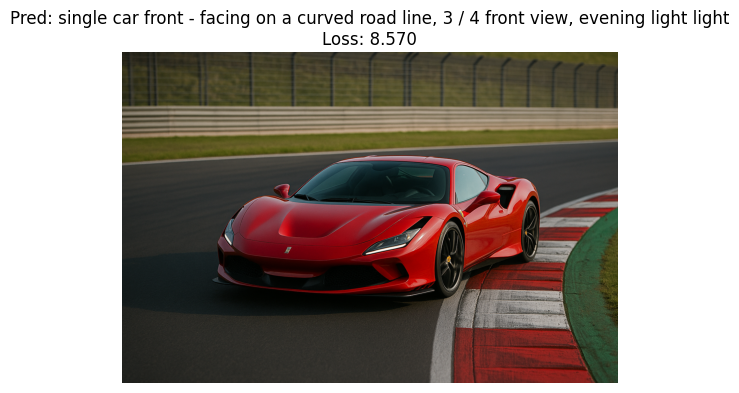

In [23]:
def get_caption_and_loss(model, processor, image, reference_caption="a car"):
    """
    Generate a caption and compute loss against a reference caption.
    """
    inputs = processor(images=image, text=reference_caption,
                       return_tensors="pt", truncation=True, padding=True).to(device)
    outputs = model(**inputs, labels=inputs["input_ids"])
    loss = outputs.loss.item()

    gen_inputs = processor(images=image, return_tensors="pt").to(device)
    out = model.generate(**gen_inputs, max_new_tokens=20)
    pred_caption = processor.decode(out[0], skip_special_tokens=True)

    return pred_caption, loss

# Path to external car image
external_img_path = REPO / "data" / "external" / "car_external.jpg"

if not external_img_path.exists():
    print(f"⚠️ External image not found: {external_img_path}")
else:
    image = Image.open(external_img_path).convert("RGB")
    pred_caption, ext_loss = get_caption_and_loss(model, processor, image, reference_caption="a car")

    # Compare numbers
    print("🔎 External Non-Member Results")
    print(f"Predicted Caption: {pred_caption}")
    print(f"External Loss: {ext_loss:.4f}")
    print(f"Avg Train Loss: {train_losses.mean():.4f}")
    print(f"Avg Test Loss: {test_losses.mean():.4f}")

    # Save figure
    plt.imshow(image)
    plt.axis("off")
    plt.title(f"Pred: {pred_caption}\nLoss: {ext_loss:.3f}")
    ext_path = FIGURES_DIR / "external_nonmember.png"
    plt.savefig(ext_path)
    print("✅ Saved external non-member demo to:", ext_path)